# WD-leak run (before the Q-fix) — forcing sensitivity
Training run `best_sweep_wdleak_fixed_gt` (config_best_sweep_wdleak_fixed_gt.yaml): the OLD forcing bug
deliberately restored — ground-truth WD prescribed at the 7 source cells (type_BC=1), no discharge input.

Main deliverable: the hydrograph-scaling test (BC × 0, 0.5, 1, 1.5, 2).
Expected: **flat line at every factor, including 0** — the model reads the flood from the leaked WD
and from the warm-start state, so scaling the forcing changes nothing.
Compare with the Q-trained model (binary switch: collapses at 0, flat elsewhere) = the "before/after the fix" figure.

Metrics use warmup_steps=0, consistent with the ruler.

In [1]:
import sys, os
os.environ.setdefault('OMP_NUM_THREADS', '1')   # local torch crashes if multithreaded
os.environ.setdefault('MKL_NUM_THREADS', '1')

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config, get_CSI
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.dataset import separate_multiscale_node_features
from utils.visualization import PlotRollout
from training.train import LightningTrainer, rollout_test_warmstart

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: /p/11210554-dtc-hydrology-next/marrocol/mSWE-GNN_marg


## Helper: load a dataset + a checkpoint pair
The wdleak model must be evaluated on the **wdleak dataset** (its BC is WD, type_BC=1), while the
baseline Q model uses the normal dataset (BC is discharge, type_BC=2). So the loader takes the config.

In [2]:
def load_setup(config_path):
    '''Load config + test dataset. Returns everything needed for evaluation.'''
    cfg = read_config(config_path)
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg, reinit=True)
    fix_dict_in_config(wandb)
    config = wandb.config
    device = torch.device('cpu')

    _, _, test_dataset, scalers = create_model_dataset(
        scalers=config.scalers, device=device,
        **config.dataset_parameters,
        **config.selected_node_features,
        **config.selected_edge_features
    )
    ttdp = get_temporal_test_dataset_parameters(config, config.temporal_dataset_parameters)
    temporal_test = to_temporal_dataset(test_dataset, rollout_steps=-1, **ttdp)
    return dict(config=config, device=device, test_dataset=test_dataset, scalers=scalers,
                ttdp=ttdp, temporal_test=temporal_test,
                num_node_features=temporal_test[0].x.size(-1),
                num_edge_features=temporal_test[0].edge_attr.size(-1))


def load_model(setup, checkpoint_path):
    '''Load one checkpoint into a model (architecture auto-detected from state_dict).'''
    config = setup['config']
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = setup['test_dataset'][0].mesh.num_meshes

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict']
    model_parameters['hid_features'] = sd['model.edge_encoder.0.weight'].shape[0]
    proc_ids = sorted(set(int(k.split('.')[2]) for k in sd
                          if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k))
    model_parameters['K'] = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids]

    model = get_model(model_type)(
        num_node_features=setup['num_node_features'],
        num_edge_features=setup['num_edge_features'],
        previous_t=setup['ttdp']['previous_t'],
        device=setup['device'],
        **model_parameters
    ).to(setup['device'])

    plmodule = LightningTrainer.load_from_checkpoint(
        checkpoint_path, map_location=setup['device'],
        model=model, lr_info=config['lr_info'], trainer_options=config.trainer_options,
        temporal_test_dataset_parameters=setup['ttdp'])
    model = plmodule.model.to(setup['device'])
    model.eval()
    print(f'  loaded {os.path.basename(checkpoint_path)}  epoch={ckpt.get("epoch", -1)}')
    return model


def forcing_sensitivity(model, setup, factors=(0.0, 0.5, 1.0, 1.5, 2.0)):
    '''Scale the BC hydrograph and measure the response (CSI vs 1x truth, WD sums).'''
    td = setup['temporal_test'][0]
    node_ptr = setup['test_dataset'][0].node_ptr
    gt_s0 = separate_multiscale_node_features(td.y.detach(), node_ptr)[0]
    t_peak = int(gt_s0[:, 0, :].clamp(min=0).sum(0).argmax())

    rows = []
    for f in factors:
        tdf = td.clone()
        tdf.BC = td.BC * f
        with torch.no_grad():
            pred = rollout_test_warmstart(model, tdf, warmup_steps=0).detach()
        p_s0 = separate_multiscale_node_features(pred, node_ptr)[0]
        csi = get_CSI(p_s0, gt_s0, water_threshold=0.05).nanmean().item()
        ws = p_s0[:, 0, :].clamp(min=0).sum(0)
        rows.append(dict(factor=f, csi_005=csi,
                         wdsum_peak=float(ws[t_peak]), wdsum_end=float(ws[-1]),
                         max_wd=float(p_s0[:, 0, :].max())))
        print(f'  BC x {f:3.1f}:  CSI@0.05={csi:.4f}   WDsum@peak(t{t_peak})={ws[t_peak]:8.0f}   '
              f'WDsum@end={ws[-1]:8.0f}   maxWD={p_s0[:,0,:].max():.2f} m')

    ws_gt = gt_s0[:, 0, :].clamp(min=0).sum(0)
    print(f'  ground truth (1x): WDsum@peak={ws_gt[t_peak]:.0f}   WDsum@end={ws_gt[-1]:.0f}')
    return rows, float(ws_gt[t_peak]), t_peak

## Part A — WD-leak model (on the wdleak dataset)

In [ ]:
setup_leak = load_setup('config_best_sweep_wdleak_fixed_gt.yaml')
print('type_BC =', int(setup_leak['test_dataset'][0].type_BC), ' (1 = WD leak)')

CKPT_LEAK = os.path.join(REPO_ROOT, 'results', 'best_sweep_wdleak_fixed_gt.h5')
model_leak = load_model(setup_leak, CKPT_LEAK)

The validation dataset you are using is the training one. Careful!


type_BC = 1  (1 = WD leak)


  loaded best_sweep_wdleak_fixed_gt_bestCSI.h5  epoch=90


/u/marrocol/.conda/envs/mswe-gnn/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:55: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [4]:
# standard metrics for reference (warmup_steps=0, same protocol as the ruler)
pr_leak = PlotRollout(model_leak, setup_leak['test_dataset'][0], scalers=setup_leak['scalers'],
                      warmup_steps=0, **setup_leak['ttdp'])
rl = pr_leak._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_wd = rl[0].item() if rl.ndim > 0 else rl.item()
print(f"RMSE_WD={rmse_wd:.4f} m   "
      f"CSI@0.05={pr_leak._get_CSI(water_threshold=0.05).nanmean().item():.4f}   "
      f"CSI@0.30={pr_leak._get_CSI(water_threshold=0.30).nanmean().item():.4f}")
print('(high scores here are expected — the model reads the GT it is evaluated against)')

RMSE_WD=0.2461 m   CSI@0.05=0.8004   CSI@0.30=0.7901
(high scores here are expected — the model reads the GT it is evaluated against)


In [5]:
print('WD-leak model — forcing sensitivity:')
rows_leak, ws_gt_peak, t_peak = forcing_sensitivity(model_leak, setup_leak)

WD-leak model — forcing sensitivity:


  BC x 0.0:  CSI@0.05=0.7981   WDsum@peak(t75)=    4423   WDsum@end=    1892   maxWD=10.52 m


  BC x 0.5:  CSI@0.05=0.7997   WDsum@peak(t75)=    4418   WDsum@end=    1890   maxWD=10.51 m


  BC x 1.0:  CSI@0.05=0.8004   WDsum@peak(t75)=    4424   WDsum@end=    1893   maxWD=10.51 m


  BC x 1.5:  CSI@0.05=0.8003   WDsum@peak(t75)=    4433   WDsum@end=    1896   maxWD=10.51 m


  BC x 2.0:  CSI@0.05=0.8000   WDsum@peak(t75)=    4441   WDsum@end=    1895   maxWD=10.52 m
  ground truth (1x): WDsum@peak=7767   WDsum@end=2519


## Part B — Q-trained baseline (on the normal dataset), for the before/after figure

In [6]:
setup_q = load_setup('config_best_sweep.yaml')
print('type_BC =', int(setup_q['test_dataset'][0].type_BC), ' (2 = discharge)')

CKPT_Q = os.path.join(REPO_ROOT, 'results', 'best_sweep_new_gt_bestCSI.h5')
model_q = load_model(setup_q, CKPT_Q)

print('Q-trained model — forcing sensitivity:')
rows_q, _, _ = forcing_sensitivity(model_q, setup_q)

The validation dataset you are using is the training one. Careful!


type_BC = 2  (2 = discharge)
  loaded best_sweep_new_gt_bestCSI.h5  epoch=632
Q-trained model — forcing sensitivity:


/u/marrocol/.conda/envs/mswe-gnn/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:55: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


  BC x 0.0:  CSI@0.05=0.6384   WDsum@peak(t75)=     418   WDsum@end=     455   maxWD=2.10 m


  BC x 0.5:  CSI@0.05=0.7411   WDsum@peak(t75)=    7721   WDsum@end=    2039   maxWD=11.25 m


  BC x 1.0:  CSI@0.05=0.7409   WDsum@peak(t75)=    7944   WDsum@end=    2120   maxWD=10.95 m


  BC x 1.5:  CSI@0.05=0.7356   WDsum@peak(t75)=    8427   WDsum@end=    2193   maxWD=10.89 m


  BC x 2.0:  CSI@0.05=0.7114   WDsum@peak(t75)=    7761   WDsum@end=    2294   maxWD=9.37 m
  ground truth (1x): WDsum@peak=7767   WDsum@end=2519


## Before / after the Q-fix — the comparison figure

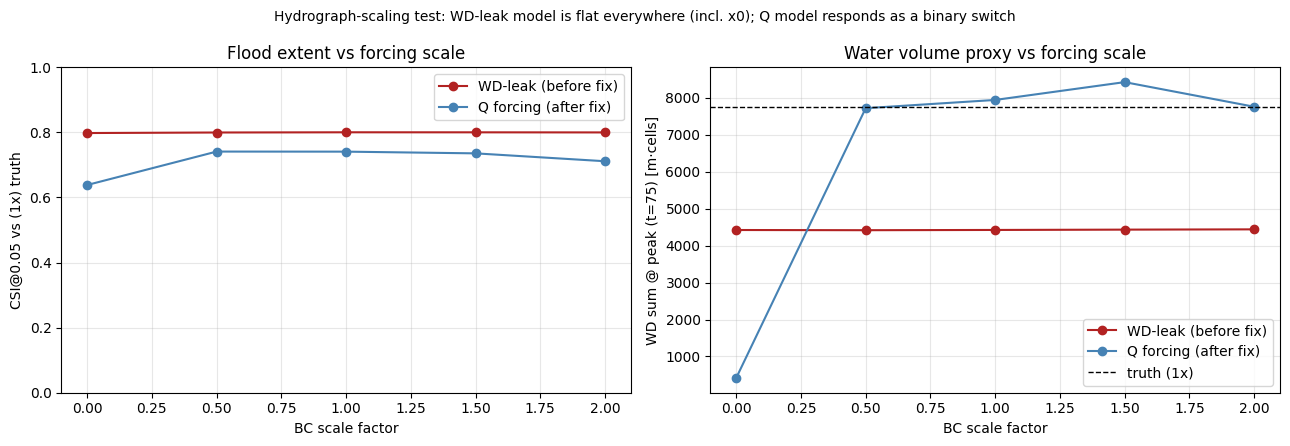

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for rows, label, color in [(rows_leak, 'WD-leak (before fix)', 'firebrick'),
                           (rows_q,    'Q forcing (after fix)', 'steelblue')]:
    fs = [r['factor'] for r in rows]
    ax[0].plot(fs, [r['csi_005'] for r in rows], 'o-', color=color, label=label)
    ax[1].plot(fs, [r['wdsum_peak'] for r in rows], 'o-', color=color, label=label)

ax[0].set_xlabel('BC scale factor'); ax[0].set_ylabel('CSI@0.05 vs (1x) truth')
ax[0].set_title('Flood extent vs forcing scale'); ax[0].set_ylim(0, 1); ax[0].grid(alpha=0.3)
ax[1].axhline(ws_gt_peak, ls='--', c='k', lw=1, label='truth (1x)')
ax[1].set_xlabel('BC scale factor'); ax[1].set_ylabel(f'WD sum @ peak (t={t_peak}) [m·cells]')
ax[1].set_title('Water volume proxy vs forcing scale'); ax[1].grid(alpha=0.3)
ax[0].legend(); ax[1].legend()
plt.suptitle('Hydrograph-scaling test: WD-leak model is flat everywhere (incl. x0); Q model responds as a binary switch', fontsize=10)
plt.tight_layout()
plt.show()